<a href="https://colab.research.google.com/github/adrian-007-cloud/Data-Science-Group-2/blob/main/DATA_SCIENCE_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PHASE 1: Setup


• Import libraries: pandas, numpy, matplotlib, seaborn

• Load the dataset with pd.read_csv()

• Filter down to the chosen state

• Confirm the filtered shape — households and children remaining

In [7]:
# pandas is our main library for working with tabular data.
# We will use it to load, inspect, clean, filter, group and analyze our dataset.
import pandas as pd

# NumPy is used for numerical operations.
import numpy as np

# Matplotlib is our base visualization library.
import matplotlib.pyplot as plt

# Seaborn is built on top of Matplotlib and makes statistical charts easier.
import seaborn as sns

In [8]:
# Read the CSV file and store it in a pandas DataFrame.
# Make sure the filename matches the file you uploaded into Colab.
df = pd.read_csv("/content/drive/MyDrive/Data science project dataset.csv")

# Check how many rows and columns we have in the FULL dataset (all 6 states).
df.shape

/tmp/ipykernel_917/2841372109.py:3: DtypeWarning: Columns (7,20,56) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/drive/MyDrive/Data science project dataset.csv")


(49408, 72)

In [9]:
# Our group decided to focus on one state instead of all 6, to keep the
# project manageable. We chose Akwa Ibom because it has the least missing
# data in our key academic outcome columns (English level, numeracy level).

# .str.strip() removes any extra spaces, .str.lower() makes the comparison
# case-insensitive, so we don't miss rows due to inconsistent capitalization.
df_ak = df[df['statename'].str.strip().str.lower() == 'akwa ibom'].copy()

# Confirm the new, smaller shape.
df_ak.shape

(6943, 72)

PHASE 2: Understand and Inspect the Data

• df.head(), df.tail() — see the raw data

• df.shape, df.columns — row/column count

• df.info() — data types, non-null counts

• df.describe() — summary stats for numeric columns

• df.nunique() and .unique() on key categorical columns

• Flag the 999 code wherever it appears — it is the missing/non-response marker, not a real value

In [10]:
#Displays the first five rows in our dataset
df_ak.head()

,statename,statecode,lg_name,lg_code,ea_code,hh_code,ch_code,hh_headage,hh_headsex,hheadedu,...,locallanglevel,lllevelcompreq1,lllevelcompreq2,numeracylevel,ethnomaths,bonus,schoolingstatus,outofschool,weight,assessed
0,Akwa Ibom,300,OBOT AKARA,1005,1007,122,300151007122C00001,35,male,999,...,NaN,NaN,NaN,NaN,NaN,NaN,Out of School,Out of School,26,NaN
1,Akwa Ibom,300,OBOT AKARA,1005,1007,123,300151007123C00002,32,male,SSS,...,NaN,NaN,NaN,Counting,correct,NaN,Currently Enrolled,NaN,26,1.0
2,Akwa Ibom,300,OBOT AKARA,1005,1007,124,300151007124C00003,60,male,999,...,NaN,NaN,NaN,NaN,NaN,NaN,Out of School,Out of School,26,NaN
3,Akwa Ibom,300,OBOT AKARA,1005,1007,125,300151007125C00004,48,male,999,...,NaN,NaN,NaN,NaN,NaN,NaN,Out of School,Out of School,26,NaN
4,Akwa Ibom,300,OBOT AKARA,1005,1007,126,300151007126C00005,68,male,999,...,NaN,NaN,NaN,NaN,NaN,NaN,Out of School,Out of School,26,NaN


In [11]:
# Display column names, data types, and how many non-missing values each
# column has. This helps us spot which columns will need cleaning.
df_ak.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6943 entries, 0 to 6942
Data columns (total 72 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   statename                    6943 non-null   object 
 1   statecode                    6943 non-null   int64  
 2   lg_name                      6943 non-null   object 
 3   lg_code                      6943 non-null   int64  
 4   ea_code                      6943 non-null   int64  
 5   hh_code                      6943 non-null   int64  
 6   ch_code                      6943 non-null   object 
 7   hh_headage                   6943 non-null   object 
 8   hh_headsex                   6943 non-null   object 
 9   hheadedu                     6943 non-null   object 
 10  hnumbermale                  6943 non-null   int64  
 11  hnumberfemale                6943 non-null   int64  
 12  hsewalls                     6943 non-null   object 
 13  hseownership           

In [12]:
# Generate descriptive statistics for the numeric columns
# (count, mean, std, min, max, quartiles).
df_ak.describe()

,statecode,lg_code,ea_code,hh_code,hnumbermale,hnumberfemale,mealsaday,childage,dropoutyear,agestartsch,samplenumber,weight,assessed
count,6943.0,6943.000000,6943.000000,6943.000000,6943.000000,6943.000000,6943.000000,6411.000000,27.000000,5177.000000,6203.000000,6943.000000,6380.0
mean,300.0,1003.428489,1089.804407,2021.101397,523.379231,76.904076,79.019156,8.893620,1224.888889,45.693452,84.820409,23.287052,1.0
std,0.0,1.633357,52.041324,1197.705521,497.605337,261.023702,265.574847,3.494043,430.650343,197.009838,275.392655,6.756570,0.0
min,300.0,1001.000000,1001.000000,1.000000,1.000000,1.000000,1.000000,3.000000,999.000000,4.000000,1.000000,12.000000,1.0
25%,300.0,1002.000000,1044.000000,991.500000,3.000000,2.000000,2.000000,6.000000,999.000000,4.000000,1.000000,19.000000,1.0
50%,300.0,1003.000000,1088.000000,1970.000000,999.000000,3.000000,3.000000,8.000000,999.000000,5.000000,2.000000,24.000000,1.0
75%,300.0,1005.000000,1136.000000,3060.500000,999.000000,4.000000,3.000000,12.000000,999.000000,6.000000,3.000000,29.000000,1.0
max,300.0,1006.000000,1180.000000,4155.000000,999.000000,999.000000,999.000000,15.000000,2017.000000,999.000000,999.000000,32.000000,1.0


In [13]:
# Check how many missing (NaN) values exist in each column.
# Note: this will NOT catch the '999' missing-code yet — that's a separate
# check, because 999 is stored as a normal value, not as NaN.
df_ak.isnull().sum()

,0
statename,0
statecode,0
lg_name,0
lg_code,0
ea_code,0
...,...
bonus,769
schoolingstatus,2
outofschool,6372
weight,0


In [14]:
# Check the total number of missing (NaN) values in the entire dataset.
df_ak.isnull().sum().sum()

np.int64(88430)

In [15]:
# Duplicate records can cause us to count the same child/household more
# than once, so we check before deciding whether to remove anything.
df_ak.duplicated().sum()

np.int64(0)

In [16]:
# This survey uses '999' as a code for "no response" / not applicable,
# instead of leaving the cell blank. Pandas treats '999' as a real value,
# not as missing, so we need to check for it separately.
#
# Here we loop through every column and count how many times '999' appears,
# so we know exactly which columns are affected before we clean them.
for col in df_ak.columns:
    count_999 = (df_ak[col].astype(str) == '999').sum()
    if count_999 > 0:
        print(col, ":", count_999)

hh_code : 1
hh_headage : 317
hh_headsex : 2
hheadedu : 3032
hnumbermale : 3628
hnumberfemale : 515
hsewalls : 5487
hseownership : 2
hselight : 4195
hhlanguage : 83
hsewater : 1944
ptameetings : 2
smbcaware : 2
smbcinvolve : 22
schdist : 6943
homework : 2
mealsaday : 534
childbreakfast : 2
eatveg : 114
eatfruits : 2
eatmeatorfish : 2
hh_tv : 2
hh_computer : 2
hh_radio : 1
hh_phone : 1
hh_animals : 4
hh_pet : 1
hh_motorveh : 1
hh_bike : 1
hh_bicycle : 1
hh_motorthrewheel : 1
hh_camelsdonkey : 1
hh_boatcanoe : 1
ch_gender : 3
childedu : 2
chd_reasonneverenolled : 143
dropoutreason : 11
enrolclass : 47
reasonfornotenrollingatage6 : 2
prepri : 2
schtype : 49
educpay : 54
anyeduc : 6148
childhealthch : 6935
ethnomaths : 375


In [17]:
# '999' is this survey's code for missing/no response. Pandas currently
# treats it as a real value, which would badly distort any averages or
# counts if we left it as-is. We replace every version of it (whether
# stored as the number 999, the number 999.0, or the text "999") with
# a proper NaN, so pandas recognizes it as genuinely missing.
df_ak = df_ak.replace([999, 999.0, '999'], np.nan)

# Drop schdist entirely — it is 999 (missing) for every single row,
# so it carries no usable information for our analysis.
df_ak = df_ak.drop(columns=['schdist'])

# Recheck total missing values now that 999 has been properly converted.
df_ak.isnull().sum().sum()

/tmp/ipykernel_917/1451325329.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_ak = df_ak.replace([999, 999.0, '999'], np.nan)


np.int64(122855)

In [18]:
# Confirm shape after dropping schdist (should now be 71 columns).
df_ak.shape

(6943, 71)

In [19]:
# Check data types again — now that 999 has been replaced with NaN,
# some columns may show differently (e.g. numeric columns that had
# '999' as text may now read as proper floats).
df_ak.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6943 entries, 0 to 6942
Data columns (total 71 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   statename                    6943 non-null   object 
 1   statecode                    6943 non-null   int64  
 2   lg_name                      6943 non-null   object 
 3   lg_code                      6943 non-null   int64  
 4   ea_code                      6943 non-null   int64  
 5   hh_code                      6942 non-null   float64
 6   ch_code                      6943 non-null   object 
 7   hh_headage                   6626 non-null   float64
 8   hh_headsex                   6941 non-null   object 
 9   hheadedu                     3911 non-null   object 
 10  hnumbermale                  3315 non-null   float64
 11  hnumberfemale                6428 non-null   float64
 12  hsewalls                     1456 non-null   object 
 13  hseownership           

PHASE 3: Data Quality Check and Data Cleaning

• df.isnull().sum() — missing values per column

• Separate structurally missing columns (e.g. dropout fields, expected to be missing) from genuinely missing
columns

• df.duplicated().sum() — check for duplicate rows

• Standardize inconsistent text (e.g. “Owned” vs “OWNED”)

• Replace 999 with proper NaN

• Handle missing numerical data (median fill where appropriate)

• Handle missing categorical data (mode fill, or “Not Applicable” where missingness is structural)

• Re-run df.isnull().sum() to confirm what remains and why

In [20]:
# These numeric columns have a manageable amount of genuine missing data.
# We fill them with the median instead of the mean, because median is
# less affected by extreme outliers (e.g. a few unusually old household heads).

df_ak['hh_headage'] = df_ak['hh_headage'].fillna(df_ak['hh_headage'].median())
df_ak['childage'] = df_ak['childage'].fillna(df_ak['childage'].median())
df_ak['mealsaday'] = df_ak['mealsaday'].fillna(df_ak['mealsaday'].median())

# Confirm these three columns now have zero missing values.
df_ak[['hh_headage', 'childage', 'mealsaday']].isnull().sum()

,0
hh_headage,0
childage,0
mealsaday,0


In [21]:
# These categorical columns have missing values that represent genuine
# non-response, not a structural skip pattern. We fill each one with its
# most common (mode) value, which is standard practice for categorical data.

cols_to_fill_mode = [
    'hheadedu', 'hsewalls', 'hselight', 'hsewater',
    'hh_tv', 'hh_computer', 'hh_radio', 'hh_phone',
    'hh_motorveh', 'hh_bike', 'hh_bicycle', 'hh_animals', 'hh_pet',
    'schtype', 'hseownership'
]

for col in cols_to_fill_mode:
    df_ak[col] = df_ak[col].fillna(df_ak[col].mode()[0])

# Confirm these columns now have zero missing values.
df_ak[cols_to_fill_mode].isnull().sum()

,0
hheadedu,0
hsewalls,0
hselight,0
hsewater,0
hh_tv,0
hh_computer,0
hh_radio,0
hh_phone,0
hh_motorveh,0
hh_bike,0


In [70]:
# These columns are missing ON PURPOSE because the question didn't apply
# to that child (e.g. no dropout reason because they never dropped out).
# Filling these in would be dishonest — it would invent information that
# doesn't exist. Instead, we simply replace NaN with a clear label so it's
# obvious in our analysis that "Not Applicable" is a real, meaningful category,
# not an accident.

structural_cols = [
    'dropoutreason', 'dropoutclass', 'dropoutyear',
    'childhealthch', 'anyeduc', 'chd_reasonneverenolled'
]

for col in structural_cols:
    df_ak[col] = df_ak[col].fillna('Not Applicable')

# Note: englevel and numeracylevel are deliberately NOT filled here.
# They stay as NaN because we need to use them to BUILD our resilience
# variable later, and filling them now would corrupt that calculation.

In [23]:
# These two columns are missing in over half the dataset, which is too
# much to reliably fill or use. We drop them rather than risk introducing
# bias into our analysis.

df_ak = df_ak.drop(columns=['hnumbermale', 'hnumberfemale'])

# Final check: confirm total missing values remaining, and new shape.
print("Remaining missing values:", df_ak.isnull().sum().sum())
print("New shape:", df_ak.shape)

Remaining missing values: 61633
New shape: (6943, 69)


In [24]:
# Let's see exactly which columns still have missing values, and how many.
# This tells us whether the remaining missingness is expected (structural,
# like englevel being blank for kids who were never assessed) or something
# we still need to handle.
remaining = df_ak.isnull().sum()
remaining = remaining[remaining > 0].sort_values(ascending=False)
remaining

,0
testlang,6943
locallanglevel,6939
lllevelcompreq2,6923
lllevelcompreq1,6923
reasonfornotenrollingatage6,6918
outofschool,6372
englevelcompreq2,4637
englevelcompreq1,4636
agestartsch,1978
samplenumber,1256


In [25]:
# These columns are almost entirely empty for Akwa Ibom specifically
# (the local-language assessment doesn't appear to have been administered
# here), so there is no real information to analyze. We also drop
# samplenumber since it's just an internal assessment ID, not something
# relevant to our research questions.

df_ak = df_ak.drop(columns=[
    'testlang', 'locallanglevel', 'lllevelcompreq1', 'lllevelcompreq2',
    'samplenumber'
])

In [26]:
# These columns are blank ON PURPOSE because the question only applied to
# certain children (e.g. englevelcompreq1 only applies to kids who reached
# a certain English level; agestartsch only applies to kids who are
# enrolled). We label these clearly instead of guessing values.

structural_cols_2 = [
    'outofschool', 'englevelcompreq1', 'englevelcompreq2', 'agestartsch',
    'reasonfornotenrollingatage6', 'ethnomaths', 'prepri', 'bonus',
    'homework', 'languageofinstr', 'educpay', 'schsurveyed', 'enrolclass'
]

for col in structural_cols_2:
    df_ak[col] = df_ak[col].fillna('Not Applicable')

In [27]:
# 'assessed' is really a Yes/No flag (1 = child was assessed). Missing
# here means the child was NOT assessed, so we fill with 0 instead of
# a text label, to keep it usable as a numeric flag.
df_ak['assessed'] = df_ak['assessed'].fillna(0)

# Drop the single row with a missing household ID — a household record
# with no ID isn't usable for analysis.
df_ak = df_ak.dropna(subset=['hh_code'])

In [28]:
# These columns have only a handful of missing values left (2-124 rows),
# which represent genuine non-response rather than a structural skip.
# We fill each with its most common (mode) value.

cols_to_fill_mode_2 = [
    'childhealth', 'eatveg', 'hhlanguage', 'smbcinvolve', 'ch_gender',
    'eatmeatorfish', 'smbcaware', 'hh_headsex', 'ptameetings',
    'schoolingstatus', 'eatfruits', 'childbreakfast', 'childedu',
    'hh_camelsdonkey', 'hh_boatcanoe', 'hh_motorthrewheel'
]

for col in cols_to_fill_mode_2:
    df_ak[col] = df_ak[col].fillna(df_ak[col].mode()[0])

In [29]:
# Confirm what's left. We EXPECT englevel and numeracylevel to still show
# missing values here - they are deliberately left as-is because we need
# them, untouched, to build our resilience variable in the next phase.
remaining_final = df_ak.isnull().sum()
remaining_final = remaining_final[remaining_final > 0].sort_values(ascending=False)
print(remaining_final)
print()
print("Final shape:", df_ak.shape)

englevel         826
numeracylevel    790
dtype: int64

Final shape: (6942, 64)


PHASE 5: Define Key Variables
• A. Socioeconomic Disadvantage Indicator: build a wealth/disadvantage index from asset ownership and
housing quality columns, plus household head's education

• Split households into Disadvantaged vs Not Disadvantaged using a chosen threshold

• B. Academic Outcome / Success Indicator: choose outcome measure(s) — English level, numeracy level,
and/or schooling status

• Define what counts as “succeeding” academically

• C. Resilience Definition: combine A and B — a Resilient child is disadvantaged AND academically strong

• Create the Resilient column (Yes/No)

In [30]:
# We build a simple wealth index by counting how many of these 7 household
# assets a family owns. These columns were chosen because they had almost
# no missing data (unlike hsewalls, hselight, hheadedu which were too
# incomplete to trust for this purpose).

asset_cols = [
    'hh_tv', 'hh_computer', 'hh_radio', 'hh_phone',
    'hh_motorveh', 'hh_bike', 'hh_bicycle'
]

# Convert "Yes"/"No" into 1/0 for each asset, then sum them up.
# This gives every household a score from 0 (owns nothing) to 7 (owns all).
asset_score = df_ak[asset_cols].apply(lambda col: (col == 'Yes').astype(int)).sum(axis=1)

# We also add house ownership to the index (Owned = 1, Rented = 0),
# since owning your home is also a meaningful marker of economic stability.
ownership_score = (df_ak['hseownership'] == 'Owned').astype(int)

# Combine both into a single wealth score, ranging from 0 (most disadvantaged)
# to 8 (most advantaged).
df_ak['wealth_score'] = asset_score + ownership_score

# Let's see how this score is distributed across households.
df_ak['wealth_score'].value_counts().sort_index()

,count
wealth_score,
0,38
1,391
2,842
3,1461
4,1661
5,1694
6,666
7,167
8,22


In [31]:
# We define "Disadvantaged" as households with a wealth score of 0-2
# (owning at most 2 of the 8 possible markers). This is the bottom ~18%
# of our sample, and represents a natural, meaningful break in the data
# compared to the larger cluster of households scoring 3-5.
#
# NOTE: this threshold is a judgment call, not an absolute rule. If your
# facilitator prefers a different cutoff, only this line needs to change.

df_ak['disadvantaged'] = df_ak['wealth_score'] <= 2

# Check how many households fall into each group.
df_ak['disadvantaged'].value_counts()

,count
disadvantaged,
False,5671
True,1271


In [32]:
# englevel has an order from weakest to strongest: Beginner -> Letter ->
# Word -> Paragraph -> Story. We treat a child as reaching a "strong"
# reading level if they are at Paragraph or Story level.

strong_english = ['Paragraph', 'Story']
df_ak['strong_english'] = df_ak['englevel'].isin(strong_english)

# numeracylevel also has an order, from weakest to strongest: Beginner ->
# Counting -> Number recog. (0-9) -> Number recog. (10-99) -> Addition ->
# Subtraction -> Multiplication. We treat a child as reaching "strong"
# numeracy if they can at least do Subtraction or Multiplication.

strong_numeracy = ['Subtraction', 'Multiplication']
df_ak['strong_numeracy'] = df_ak['numeracylevel'].isin(strong_numeracy)

# A child is "academically successful" if they are strong in EITHER
# English OR numeracy. We use OR (not AND) because a child could be
# strong in one area and still represent genuine academic success -
# requiring both would be a stricter, narrower definition.

df_ak['academic_success'] = df_ak['strong_english'] | df_ak['strong_numeracy']

# Check how many children are flagged as academically successful.
df_ak['academic_success'].value_counts()

,count
academic_success,
True,3868
False,3074


In [33]:
# Before combining our variables, we need to be careful: 'strong_english'
# and 'strong_numeracy' currently mark unassessed children as False, which
# wrongly implies they performed poorly. In reality, we simply don't know
# how they would have scored.
#
# To keep our resilience analysis honest, we restrict it to children who
# were ACTUALLY assessed. This is a meaningful methodological decision we
# will explain clearly in our report.

df_assessed = df_ak[df_ak['assessed'] == 1].copy()

print("Children actually assessed:", df_assessed.shape[0])
print("Children excluded (not assessed):", df_ak.shape[0] - df_assessed.shape[0])

Children actually assessed: 6379
Children excluded (not assessed): 563


PHASE 6: Outliers and Distribution Checks

• Boxplots for numeric variables (age, household size, meals/day)

• IQR method to flag unusual values

• Decide: keep, cap, or investigate further (document reasoning)

• Check distribution shape of the wealth index and resilience split


In [34]:
numeric_cols = ['hh_headage', 'childage', 'mealsaday', 'wealth_score']

df_assessed[numeric_cols].describe()

,hh_headage,childage,mealsaday,wealth_score
count,6379.000000,6379.000000,6379.000000,6379.000000
mean,44.900611,9.206459,2.339708,3.901238
std,11.518993,3.168150,0.669973,1.458089
min,17.000000,4.000000,1.000000,0.000000
25%,38.000000,7.000000,2.000000,3.000000
50%,43.000000,8.000000,2.000000,4.000000
75%,50.000000,12.000000,3.000000,5.000000
max,100.000000,15.000000,3.000000,8.000000


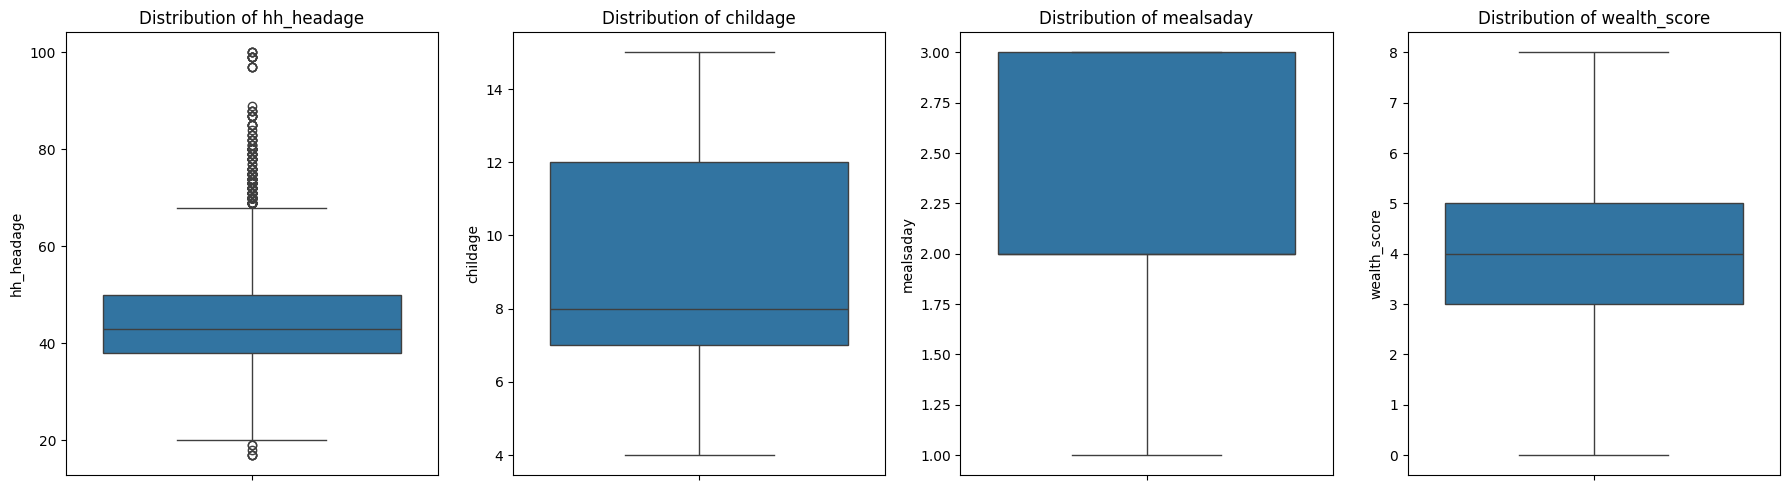

In [35]:
# Boxplots let us visually spot extreme values in each numeric column.
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df_assessed, y=col, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

In [36]:
for col in numeric_cols:
    Q1 = df_assessed[col].quantile(0.25)
    Q3 = df_assessed[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_assessed[(df_assessed[col] < lower_bound) | (df_assessed[col] > upper_bound)]

    print(f"--- {col} ---")
    print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
    print(f"Lower bound: {lower_bound}, Upper bound: {upper_bound}")
    print(f"Number of outliers: {outliers.shape[0]}")
    print()

--- hh_headage ---
Q1: 38.0, Q3: 50.0, IQR: 12.0
Lower bound: 20.0, Upper bound: 68.0
Number of outliers: 277

--- childage ---
Q1: 7.0, Q3: 12.0, IQR: 5.0
Lower bound: -0.5, Upper bound: 19.5
Number of outliers: 0

--- mealsaday ---
Q1: 2.0, Q3: 3.0, IQR: 1.0
Lower bound: 0.5, Upper bound: 4.5
Number of outliers: 0

--- wealth_score ---
Q1: 3.0, Q3: 5.0, IQR: 2.0
Lower bound: 0.0, Upper bound: 8.0
Number of outliers: 0



In [37]:
# Check skewness for each numeric column, to understand whether the
# distribution is symmetric or leans heavily to one side.

for col in numeric_cols:
    print(f"{col} skewness: {df_assessed[col].skew():.3f}")

hh_headage skewness: 0.842
childage skewness: 0.367
mealsaday skewness: -0.522
wealth_score skewness: -0.105


In [38]:
# OBSERVATION: Outliers in hh_headage (household head's age)
#
# The IQR method flagged 277 household heads above age 68 (up to age 100)
# as statistical outliers. However, these are NOT data entry errors -
# it is realistic for elderly relatives (e.g. grandparents) to be the
# head of a household raising children, which is common in many
# Nigerian households. We therefore KEEP these values as-is rather than
# removing or capping them, consistent with the principle that outliers
# should only be corrected when they represent genuine errors.
#
# OBSERVATION: Skewness
#
# All four numeric variables (hh_headage, childage, mealsaday,
# wealth_score) show only mild skewness (all values between -1 and 1).
# None require transformation for our analysis, since we are not
# building a predictive model - our work is based on EDA, cross-
# tabulation, and statistical inference, which do not require normally
# distributed inputs.

print("Outlier and skewness check complete. No transformations applied.")

Outlier and skewness check complete. No transformations applied.


In [39]:
# Now we build the final Resilient variable, using ONLY the assessed
# children. A child is "Resilient" if they come from a DISADVANTAGED
# household AND are ACADEMICALLY SUCCESSFUL despite that disadvantage.

df_assessed['Resilient'] = df_assessed['disadvantaged'] & df_assessed['academic_success']

# Check the full breakdown: how many disadvantaged children are resilient
# vs not, compared to non-disadvantaged children.
pd.crosstab(df_assessed['disadvantaged'], df_assessed['Resilient'])

Resilient,False,True
disadvantaged,,
False,5246,0
True,456,677


In [40]:
# Save our cleaned dataset (with wealth_score, disadvantaged,
# academic_success, and Resilient columns) so the rest of the group can
# pick up from exactly this point without repeating our cleaning steps.

df_assessed.to_csv('akwa_ibom_cleaned_with_resilience.csv', index=False)

from google.colab import files
files.download('akwa_ibom_cleaned_with_resilience.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

PHASE 8: Answer the Analytical Questions
• Formulate 3 to 5 questions tied directly to the project title

• For each: show the relevant chart/crosstab, state the finding, explain what it means in plain language


In [54]:
df_disadv = df_assessed[df_assessed['disadvantaged'] == True].copy()

Q1: Does resilience differ by gender?

In [59]:
df_disadv.groupby("ch_gender")["Resilient"].mean()

,Resilient
ch_gender,
female,0.615101
male,0.581356


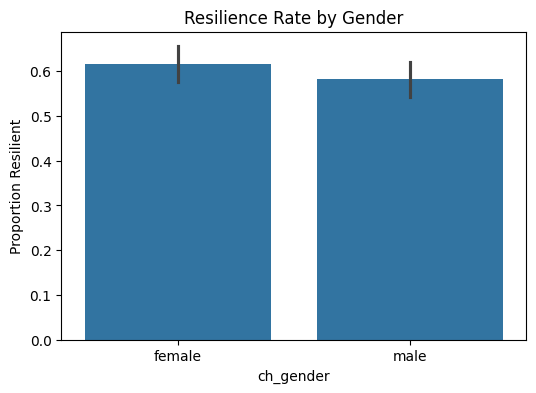

In [65]:
# Chart 1: Resilience by Gender
plt.figure(figsize=(6,4))
sns.barplot(data=df_disadv, x="ch_gender", y="Resilient", estimator="mean")
plt.title("Resilience Rate by Gender")
plt.ylabel("Proportion Resilient")
plt.show()

Girls showed a slightly higher resilience rate (61.5%) than boys (58.1%) among disadvantaged children. The gap is small, suggesting gender is not a strong differentiator of resilience in this sample.

Q2: Does PTA meeting attendance relate to resilience?

In [60]:
df_disadv.groupby("ptameetings")["Resilient"].mean()

,Resilient
ptameetings,
No,0.612137
Yes,0.590186


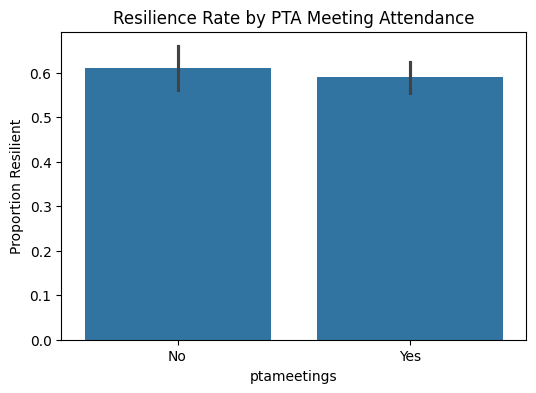

In [66]:
# Chart 2: Resilience by PTA Meetings
plt.figure(figsize=(6,4))
sns.barplot(data=df_disadv, x="ptameetings", y="Resilient", estimator="mean")
plt.title("Resilience Rate by PTA Meeting Attendance")
plt.ylabel("Proportion Resilient")
plt.show()

Households that did not attend PTA meetings actually showed a slightly higher resilience rate (61.2%) than those that did (59.0%). This is a small, counter-intuitive gap — it suggests PTA attendance alone isn't a strong driver of resilience here.

Q3: Does SMBC involvement relate to resilience?

In [61]:
df_disadv.groupby("smbcinvolve")["Resilient"].mean()

,Resilient
smbcinvolve,
No,0.591897
Yes,0.644628


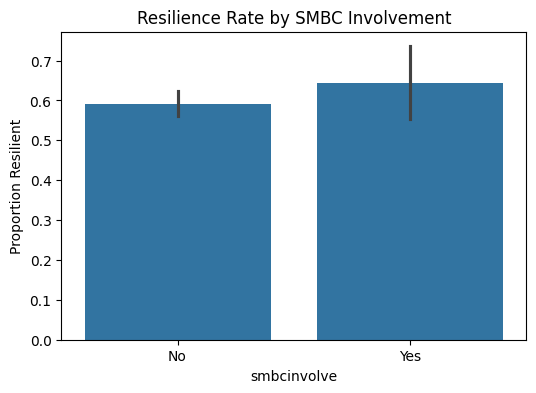

In [67]:
# Chart 3: Resilience by SMBC Involvement
plt.figure(figsize=(6,4))
sns.barplot(data=df_disadv, x="smbcinvolve", y="Resilient", estimator="mean")
plt.title("Resilience Rate by SMBC Involvement")
plt.ylabel("Proportion Resilient")
plt.show()

Children from households involved in the School-Based Management Committee had a notably higher resilience rate (64.5%) than those not involved (59.2%). This is the clearest positive relationship found in the EDA, and it aligns with expectations — deeper school governance involvement may reflect stronger engagement with a child's education.

Q4: Does household head's education relate to resilience?

In [62]:
df_disadv.groupby("hheadedu")["Resilient"].mean()

,Resilient
hheadedu,
JSS,0.551020
No Education,0.677778
PRY,0.582938
SSS,0.591160
Tetiary Education,0.644068


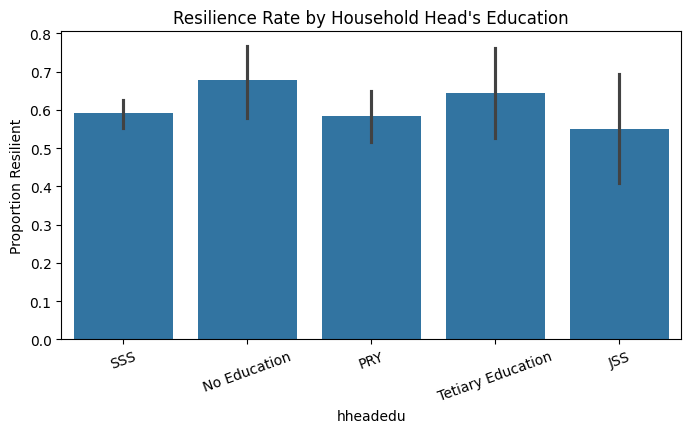

In [68]:
# Chart 4: Resilience by Household Head's Education
plt.figure(figsize=(8,4))
sns.barplot(data=df_disadv, x="hheadedu", y="Resilient", estimator="mean")
plt.title("Resilience Rate by Household Head's Education")
plt.ylabel("Proportion Resilient")
plt.xticks(rotation=20)
plt.show()

Results were mixed rather than a clean upward trend: households where the head had no formal education actually showed the highest resilience rate (67.8%), while JSS-level education showed the lowest (55.1%). Tertiary education households were also high (64.4%). This suggests household head's education alone does not predict resilience in a simple way — other factors are likely interacting with it.

Q5: Does school type relate to resilience?

In [63]:
df_disadv.groupby("schtype")["Resilient"].mean()

,Resilient
schtype,
Private,0.554455
Public,0.613253


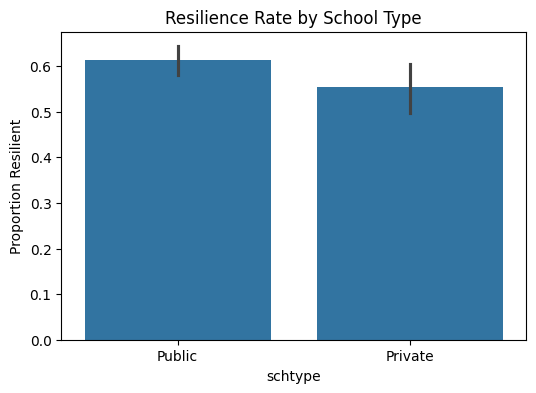

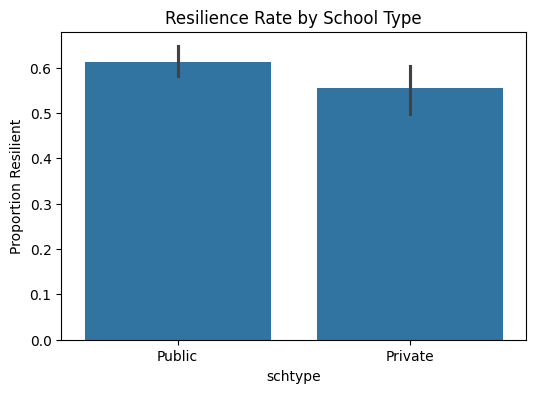

In [69]:
# Chart 5: Resilience by School Type
plt.figure(figsize=(6,4))
sns.barplot(data=df_disadv, x="schtype", y="Resilient", estimator="mean")
plt.title("Resilience Rate by School Type")
plt.ylabel("Proportion Resilient")
plt.show()# Chart 5: Resilience by School Type
plt.figure(figsize=(6,4))
sns.barplot(data=df_disadv, x="schtype", y="Resilient", estimator="mean")
plt.title("Resilience Rate by School Type")
plt.ylabel("Proportion Resilient")
plt.show()

Disadvantaged children in public schools showed higher resilience (61.3%) than those in private schools (55.4%). This may reflect that disadvantaged families who still choose private school are under greater financial strain, or that public schools serving this population are reaching these children effectively.

Q6: Does nutrition relate to resilience?

In [64]:
print(df_disadv.groupby("childbreakfast")["Resilient"].mean())
print()
print(df_disadv.groupby("eatveg")["Resilient"].mean())
print()
print(df_disadv.groupby("eatmeatorfish")["Resilient"].mean())

childbreakfast
No     0.605691
Yes    0.595265
Name: Resilient, dtype: float64

eatveg
No     0.596811
Yes    0.597983
Name: Resilient, dtype: float64

eatmeatorfish
No     0.591022
Yes    0.601093
Name: Resilient, dtype: float64


Breakfast, vegetable intake, and meat/fish intake all showed negligible differences in resilience rate (roughly 59–61% regardless of answer). Nutrition, at least as measured here, does not appear to meaningfully distinguish resilient from non-resilient children.

Overall pattern across the findings from the questions: Most individual factors show only small differences — the standout exception is SMBC involvement, and school type is a secondary point of interest. This itself is a valid, reportable conclusion: resilience in this sample doesn't appear to hinge on any single dominant factor, suggesting it's likely shaped by a combination of conditions rather than one clear driver — a nuanced, defensible takeaway for your title's "patterns of educational success."

## Phase 9: Communicate Findings

### Summary of Key Patterns

Among disadvantaged children in Akwa Ibom, **59.8% were found to be academically resilient** — meaning they came from low-wealth households (bottom ~18% by asset ownership) but still reached strong English and/or numeracy levels.

Looking across the factors tested, resilience did not appear to hinge on any single dominant driver. Instead:

- **Strongest positive pattern:** SMBC (School-Based Management Committee) involvement — resilient children were more likely to come from households engaged in school governance (64.5% vs 59.2%)
- **Second notable pattern:** School type — disadvantaged children in public schools showed higher resilience (61.3%) than those in private schools (55.4%)
- **Weak or mixed patterns:** gender, PTA attendance, household head's education, and nutrition all showed only small or inconsistent differences

**Overall takeaway:** academic resilience among disadvantaged children in this sample appears to be shaped by a combination of conditions rather than one clear factor — school-level engagement (SMBC, school type) showed more relationship to resilience than household-level factors like parental education or nutrition.

---

### Limitations

1. **Correlation, not causation** — none of these relationships prove that, say, SMBC involvement *causes* resilience. Families more engaged with school governance may differ in other unmeasured ways too.
2. **Self-reported survey data** — parents/guardians reported on household conditions and children's habits, which can introduce reporting bias.
3. **Resilience threshold is a judgment call** — "Disadvantaged" (wealth score 0-2) and "Academic Success" (Paragraph/Story English, or Subtraction/Multiplication numeracy) were thresholds we defined. A different cutoff could shift the results.
4. **Structural missingness** — some variables (like dropout reasons) only applied to certain children; we handled this by labeling rather than guessing values, which limits analysis of those subgroups.
5. **Single state** — findings are specific to Akwa Ibom and may not generalize to other Nigerian states.
6. **Household head's education result was mixed** — the "No Education" group having the highest resilience rate is counter-intuitive and worth flagging as needing further investigation rather than over-interpreting.

---

### Recommendations / Implications

- Programs that strengthen parent/community involvement in **school governance** (not just PTA attendance, but structural involvement like SMBCs) may be worth prioritizing, given this showed the clearest positive relationship with resilience.
- Further research with a larger or multi-state sample could help confirm whether the public-vs-private school pattern holds elsewhere.
- The household head's education finding suggests resilience is not simply inherited from parental attainment — pointing to the importance of school and community-level support systems, not just family background.

---

### Conclusion

This project set out to identify patterns of educational success among socioeconomically disadvantaged children in Akwa Ibom State. Using a real household survey dataset, we defined academic resilience as disadvantaged children who still reached strong academic outcomes, and found that roughly 6 in 10 disadvantaged children met this bar. School-level factors (SMBC involvement, school type) showed more relationship to resilience than